# Ultrasensitive biosensing with 3D quasi-BIC metasurfaces

This notebook demonstrates a Tidy3D implementation inspired by selected simulations from `J. Sun et al., Nature Photonics (2026)` [DOI: 10.1038/s41566-026-01909-z](https://doi.org/10.1038/s41566-026-01909-z).

The paper introduces *Q-modulated refractometric sensing (QMRS)* using a strongly coupled three-dimensional quasi-bound-state-in-the-continuum (qBIC) metasurface. Each unit cell contains two nominally identical Au/TiO₂-coated resonators positioned at different vertical depths. Their coupling produces lower and upper hybrid branches, qBIC<sub>L</sub> and qBIC<sub>U</sub>, with distinct responses to a superstrate refractive-index perturbation. The more localized qBIC<sub>L</sub> branch behaves primarily as a conventional refractometric mode and shifts in frequency. In contrast, the more non-local qBIC<sub>U</sub> branch has weaker direct analyte overlap but exhibits pronounced radiative-Q and intensity modulation with relatively little frequency shift.

Model assumptions and relation to the paper:

- Both models use FDTD simulations with periodic boundaries in $x$ and $y$, perfectly matched layers along $z$, and normal-incidence plane-wave illumination.
- The paper uses a uniform 5 nm mesh. This notebook instead uses Tidy3D's automatic nonuniform grid with 30 steps per wavelength, selected following an independent convergence study spanning 15–40 steps per wavelength.
- Au is modeled using the Johnson–Christy (1972) dispersive model. The nondispersive refractive indices are $n_\mathrm{NOA83}=1.56$, $n_\mathrm{TiO_2}=2.20$, and $n_\mathrm{sup}=1.33+\Delta n$.
- Unless otherwise stated, the geometric dimensions below are simulation inputs used in this notebook and may not exactly match those reported in the paper.


<!-- ![Thumbnail](qbic_metasurface_5x5_3.png) -->

<img src="./img/qbic_metasurface.png" width="500" alt="Schematic of the metasurface">

## Simulation Setup

In [1]:
import tidy3d as td
import tidy3d.web as web

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

td.config.logging_level = "ERROR"

#### SWIR device parameters
The parameters below model the paper's short-wave-infrared design ($P=800$ nm) over 0.84–1.02 eV (approximately 1.22–1.48 µm). All geometric quantities are expressed in micrometres, the native length unit in Tidy3D. Photon energies are converted to frequencies through $E=2\pi\hbar f$.

In [2]:
# Spectral range — SWIR device
photon_energy_min = 0.84  # eV
photon_energy_max = 1.02  # eV

P = 0.8  # unit cell period (µm)
P2 = P * np.sqrt(2)  # doubled supercell period (µm)

fmin = photon_energy_min / td.HBAR / (2 * np.pi)
fmax = photon_energy_max / td.HBAR / (2 * np.pi)
freq0 = (fmin + fmax) / 2
fwidth = fmax - fmin
wvl0 = td.C_0 / freq0

freqs = np.linspace(fmin, fmax, 241)
source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth)

nm = 1e-3  # nanometre in Tidy3D units (µm)

# Materials
Au = td.material_library["Au"]["JohnsonChristy1972"]
TiO2 = td.Medium.from_nk(n=2.2, k=0, freq=freq0)
NOA83 = td.Medium.from_nk(n=1.56, k=0, freq=freq0)

wvl_eff = wvl0 / NOA83.nk_model(frequency=freq0)[0]  # effective wavelength in substrate
wvl_water = wvl0 / 1.33  # effective wavelength in substrate

# Base geometry (µm) — passed explicitly to make_sim / make_sim2
D_A = 300 * nm  # particle-A diameter
D_B = D_A  # particle-B diameter (symmetric base case)
Z_A = 200 * nm  # particle-A hole depth
del_Z = 120 * nm
Z_B = Z_A - del_Z  # particle-B hole depth

buffer = 0.2
sim_size_z_plus = (
    buffer + 1 * wvl_water
)  # simulation size in z direction (used as global inside make_sim / make_sim2)
sim_size_z_minus = (
    buffer + 3 * wvl_eff
)  # simulation size in z direction (used as global inside make_sim / make_sim2)

#### Unit cell simulation

The primitive square cell contains one A site and one B site. Au and TiO₂ conformal layers occupy cylindrical recesses in the NOA83 substrate and continue across the top surface. A normally incident, $x$-polarized plane wave propagates from the substrate toward the aqueous superstrate.

In [3]:
def make_sim(
    D_A: float = 0.3,
    D_B: float = 0.3,
    Z_A: float = 0.2,
    Z_B: float = 0.08,
    t_TiO2: float = 130e-3,
    t_Au: float = 50e-3,
    deln_bulk: float = 0.0,
    min_steps_per_wvl: int = 30,
) -> td.Simulation:
    """Primitive-cell FDTD simulation.

    Parameters (all lengths in µm):
        D_A, D_B        : nanohole diameters for particles A and B
        Z_A, Z_B        : nanohole depths for particles A and B
        t_TiO2, t_Au    : TiO₂ and Au film thicknesses
        deln_bulk       : superstrate refractive-index offset from n=1.33
        min_steps_per_wvl: auto-grid resolution
    """
    hole_A = td.Cylinder(
        axis=2, center=(P / 4, P / 4, -Z_A / 2), radius=D_A / 2, length=Z_A
    )
    hole_B = td.Cylinder(
        axis=2, center=(-P / 4, -P / 4, -Z_B / 2), radius=D_B / 2, length=Z_B
    )

    geom_sub = td.ClipOperation(
        operation="difference",
        geometry_a=td.Box(
            center=(0, 0, -sim_size_z_minus),
            size=(td.inf, td.inf, sim_size_z_minus * 2),
        ),
        geometry_b=td.GeometryGroup(geometries=[hole_A, hole_B]),
    )
    substrate = td.Structure(geometry=geom_sub, medium=NOA83, name="substrate")

    deposit_au_A = td.Structure(
        geometry=td.Cylinder(
            axis=2, center=(P / 4, P / 4, -Z_A + t_Au / 2), radius=D_A / 2, length=t_Au
        ),
        medium=Au,
        name="au-A",
    )
    deposit_au_B = td.Structure(
        geometry=td.Cylinder(
            axis=2,
            center=(-P / 4, -P / 4, -Z_B + t_Au / 2),
            radius=D_B / 2,
            length=t_Au,
        ),
        medium=Au,
        name="au-B",
    )
    deposit_au_sub = td.Structure(
        geometry=td.ClipOperation(
            operation="difference",
            geometry_a=td.Box(center=(0, 0, t_Au / 2), size=(td.inf, td.inf, t_Au)),
            geometry_b=td.GeometryGroup(
                geometries=[
                    td.Cylinder(
                        axis=2,
                        center=(-P / 4, -P / 4, t_Au / 2),
                        radius=D_B / 2,
                        length=t_Au,
                    ),
                    td.Cylinder(
                        axis=2,
                        center=(P / 4, P / 4, t_Au / 2),
                        radius=D_A / 2,
                        length=t_Au,
                    ),
                ]
            ),
        ),
        medium=Au,
        name="au-sub",
    )
    deposit_au = [deposit_au_A, deposit_au_B, deposit_au_sub]

    deposit_tio2_A = td.Structure(
        geometry=td.Cylinder(
            axis=2,
            center=(P / 4, P / 4, -Z_A + t_Au + t_TiO2 / 2),
            radius=D_A / 2,
            length=t_TiO2,
        ),
        medium=TiO2,
        name="TiO2-A",
    )
    deposit_tio2_B = td.Structure(
        geometry=td.Cylinder(
            axis=2,
            center=(-P / 4, -P / 4, -Z_B + t_Au + t_TiO2 / 2),
            radius=D_B / 2,
            length=t_TiO2,
        ),
        medium=TiO2,
        name="TiO2-B",
    )
    deposit_tio2_sub = td.Structure(
        geometry=td.ClipOperation(
            operation="difference",
            geometry_a=td.Box(
                center=(0, 0, t_Au + t_TiO2 / 2), size=(td.inf, td.inf, t_TiO2)
            ),
            geometry_b=td.GeometryGroup(
                geometries=[
                    td.Cylinder(
                        axis=2,
                        center=(-P / 4, -P / 4, t_Au + t_TiO2 / 2),
                        radius=D_B / 2,
                        length=t_TiO2,
                    ),
                    td.Cylinder(
                        axis=2,
                        center=(P / 4, P / 4, t_Au + t_TiO2 / 2),
                        radius=D_A / 2,
                        length=t_TiO2,
                    ),
                ]
            ),
        ),
        medium=TiO2,
        name="TiO2-sub",
    )
    deposit_tio2 = [deposit_tio2_A, deposit_tio2_B, deposit_tio2_sub]

    pw_source = td.PlaneWave(
        center=(0, 0, -buffer - 0.5 * wvl_eff),
        size=(td.inf, td.inf, 0),
        direction="+",
        source_time=source_time,
        pol_angle=0,
    )
    mnt_refl = td.FluxMonitor(
        center=(0, 0, -buffer - wvl_eff),
        size=(td.inf, td.inf, 0),
        freqs=freqs,
        name="refl",
        normal_dir="-",
    )
    mnt_trans = td.FluxMonitor(
        center=(0, 0, buffer + 0.5 * wvl_water),
        size=(td.inf, td.inf, 0),
        freqs=freqs,
        name="trans",
        normal_dir="+",
    )

    superstrate = td.Medium.from_nk(n=1.33 + deln_bulk, k=0.0, freq=freq0)

    grid_spec = td.GridSpec.auto(
        wavelength=wvl0,
        min_steps_per_wvl=min_steps_per_wvl,
        snapping_points=[
            (P / 4, P / 4, pw_source.center[2]),
            (-P / 4, -P / 4, mnt_refl.center[2]),
            (0, 0, mnt_trans.center[2]),
        ],
    )

    return td.Simulation(
        size=(P, P, sim_size_z_plus + sim_size_z_minus),
        center=(0, 0, (sim_size_z_plus - sim_size_z_minus) / 2),
        medium=superstrate,
        structures=[substrate, *deposit_au, *deposit_tio2],
        sources=[pw_source],
        monitors=[mnt_refl, mnt_trans],
        grid_spec=grid_spec,
        boundary_spec=td.BoundarySpec(
            z=td.Boundary.pml(),
            x=td.Boundary.periodic(),
            y=td.Boundary.periodic(),
        ),
        run_time=td.RunTimeSpec(quality_factor=500, source_factor=100),
        shutoff=5e-7,
    )

The 3D structure and computational grid of the base simulation are shown below.

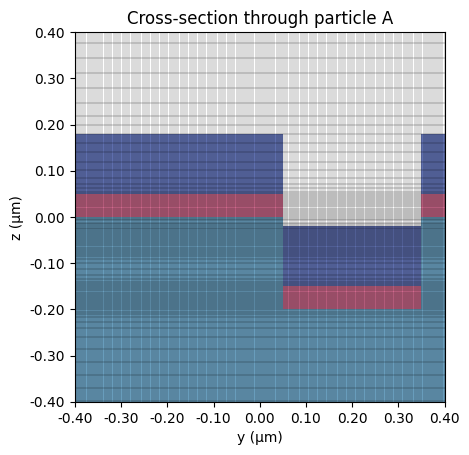

In [4]:
sim_base = make_sim()

fig, ax = plt.subplots()
sim_base.plot_grid(x=P / 4, ax=ax)
sim_base.plot(x=P / 4, ax=ax)
ax.set(
    xlim=(-P / 2, P / 2), ylim=(-P / 2, P / 2), title="Cross-section through particle A"
)

sim_base.plot_3d()

#### Grid convergence test

This implementation uses Tidy3D's automatic nonuniform grid. We therefore first perform a grid-convergence study to verify that the simulated spectral response is insensitive to further mesh refinement.

In [5]:
sims = {f"{n}-step": make_sim(min_steps_per_wvl=n) for n in [15, 20, 25, 30, 35, 40]}

batch_data = web.run_async(
    simulations=sims, verbose=True, folder_name="NatPhoton2026", path_dir="./data/conv"
)

12:21:19 KST Found all simulations in cache.

Reflectance and transmittance fluxes are used to compute the absorptance, $A = 1 - R - T$. The absorption spectra are compared across six automatic-grid resolutions spanning 15–40 steps per wavelength. Based on this comparison, the 30-steps-per-wavelength grid is selected and used throughout the remainder of this notebook.

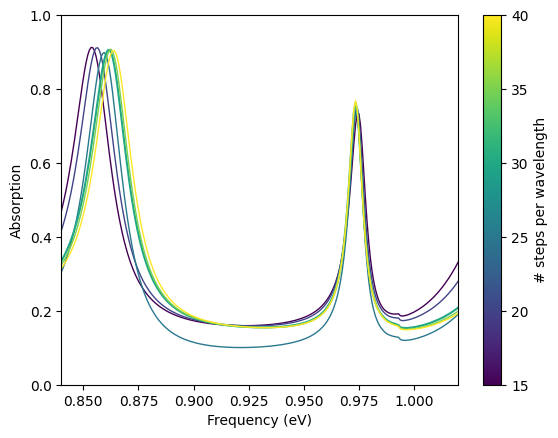

In [6]:
fig, ax = plt.subplots()
cmap = plt.cm.viridis
n_steps = [15, 20, 25, 30, 35, 40]
norm = Normalize(vmin=15, vmax=40)
for n in n_steps:
    sim_data = batch_data[f"{n}-step"]
    refl = sim_data["refl"].flux.squeeze()
    trans = sim_data["trans"].flux.squeeze()
    abs_spec = 1 - refl - trans
    f = abs_spec.f
    ax.plot(
        2 * np.pi * f * td.HBAR,
        abs_spec,
        "-",
        lw=1.5 if n == 30 else 1,
        color=cmap(norm(n)),
    )

ax.set(
    xlabel="Frequency (eV)",
    ylabel="Absorption",
    ylim=(0, 1),
    xlim=(photon_energy_min, photon_energy_max),
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"# steps per wavelength")
cbar.set_ticks(n_steps)

## Effect of asymmetry

#### In-plane symmetry breaking: diameter asymmetry

With $Z_A=Z_B=200$ nm, the diameter difference $\Delta D=D_A-D_B$ is swept from 0 to 260 nm by holding $D_A=300$ nm and decreasing $D_B$. At $\Delta D=0$, the symmetry-protected mode is ideally dark at normal incidence. A nonzero $\Delta D$ breaks the in-plane symmetry, opens radiative coupling, and produces finite-linewidth qBIC resonances. As emphasized in the paper, diameter asymmetry also perturbs the individual resonators and therefore causes eigenfrequency shifts and interbranch crosstalk.

In [7]:
delD_list = np.linspace(0, 260 * nm, 14)
sims = {
    f"deld_sweep_{ii}": make_sim(
        Z_A=200 * nm, Z_B=200 * nm, D_A=300 * nm, D_B=300 * nm - deld
    )
    for ii, deld in enumerate(delD_list)
}

batch_data = web.run_async(
    simulations=sims,
    verbose=True,
    folder_name="NatPhoton2026",
    path_dir="./data/diameter",
)

12:21:20 KST Found all simulations in cache.

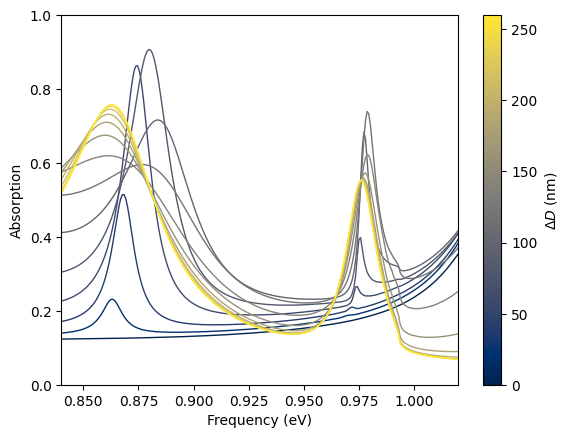

In [8]:
fig, ax = plt.subplots()
cmap = plt.cm.cividis
norm = Normalize(vmin=0, vmax=260)
for ii, deld in enumerate(delD_list):
    sim_data = batch_data[f"deld_sweep_{ii}"]
    refl = sim_data["refl"].flux.squeeze()
    trans = sim_data["trans"].flux.squeeze()
    abs_spec = 1 - refl - trans
    f = refl.f
    ax.plot(2 * np.pi * f * td.HBAR, abs_spec, "-", lw=1, color=cmap(norm(deld * 1e3)))

ax.set(
    xlabel="Frequency (eV)",
    ylabel="Absorption",
    ylim=(0, 1),
    xlim=(photon_energy_min, photon_energy_max),
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\Delta D$ (nm)")

#### Out-of-plane symmetry breaking: vertical displacement

With $D_A=D_B=300$ nm and $Z_A=200$ nm, the vertical displacement $\Delta Z=Z_A-Z_B$ is swept from 0 to 130 nm. A nonzero $\Delta Z$ breaks the out-of-plane symmetry and opens controlled radiative channels, making the lower and upper hybrid branches observable as qBIC_L and qBIC_U. Crucially, $\Delta Z$ primarily controls radiative leakage and linewidth; it does not by itself create the strong coupling or Rabi splitting. The paper contrasts this comparatively stable eigenfrequency tuning with the stronger modal crosstalk produced by diameter asymmetry.

In [9]:
delZ_list = np.linspace(0, 130 * nm, 14)
sims = {
    f"delz_sweep_{ii}": make_sim(Z_A=200 * nm, Z_B=200 * nm - delz)
    for ii, delz in enumerate(delZ_list)
}

batch_data = web.run_async(
    simulations=sims, verbose=True, folder_name="NatPhoton2026", path_dir="./data/depth"
)

12:21:21 KST Found all simulations in cache.

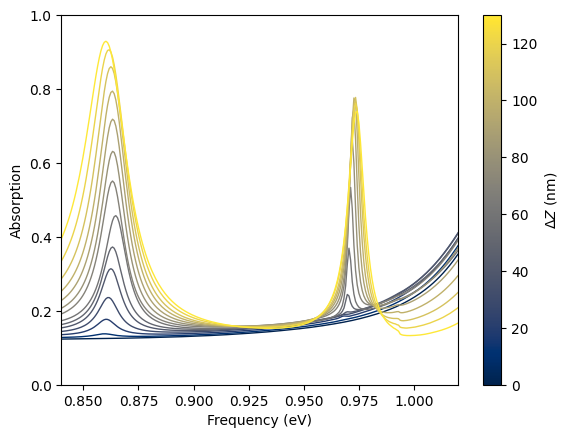

In [10]:
fig, ax = plt.subplots()
cmap = plt.cm.cividis
norm = Normalize(vmin=0, vmax=130)
for ii, delz in enumerate(delZ_list):
    sim_data = batch_data[f"delz_sweep_{ii}"]
    refl = sim_data["refl"].flux.squeeze()
    trans = sim_data["trans"].flux.squeeze()
    abs_spec = 1 - refl - trans
    f = refl.f
    ax.plot(2 * np.pi * f * td.HBAR, abs_spec, "-", lw=1, color=cmap(norm(delz * 1e3)))

ax.set(
    xlabel="Frequency (eV)",
    ylabel="Absorption",
    ylim=(0, 1),
    xlim=(photon_energy_min, photon_energy_max),
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\Delta Z$ (nm)")

## Bulk refractive-index perturbation

The simulation geometry is $Z_A=194$ nm, $Z_B=30$ nm, and $t_\mathrm{TiO_2}=60$ nm. The aqueous-superstrate perturbation is swept from $\Delta n=0$ to 0.08 RIU. 

In [11]:
deln_list = np.linspace(0, 0.08, 9)
sims = {
    f"deln_sweep_{ii}": make_sim(
        Z_A=194 * nm, Z_B=30 * nm, t_TiO2=60 * nm, deln_bulk=deln
    )
    for ii, deln in enumerate(deln_list)
}

batch_data = web.run_async(
    simulations=sims,
    verbose=True,
    folder_name="NatPhoton2026",
    path_dir="./data/deltan",
)

12:21:22 KST Found all simulations in cache.

Dashed lines mark the independently extracted qBIC_L and qBIC_U absorption peaks at both endpoints.

`peak_frequencies_from_derivatives` identifies peak frequencies from local maxima of the absorption spectrum: candidates are points where $dA/df$ changes from positive to negative and $d^2A/df^2<0$. If the sampled spectrum misses one sign change, the helper falls back to interior negative-curvature regions and chooses the point with the smallest $|dA/df|$. Only the endpoint frequencies $f_{L0}$, $f_{L1}$, and $f_U$ are extracted for the near-field simulations.

The local qBIC_L branch has relatively strong field overlap with the superstrate and therefore responds predominantly through a resonance-frequency shift, as in conventional refractometric sensing. The non-local qBIC_U branch has weaker direct analyte overlap and undergoes comparatively little frequency shift, but its radiative loss rate changes strongly. This conversion of a real refractive-index perturbation into an intensity response is the defining QMRS mechanism.

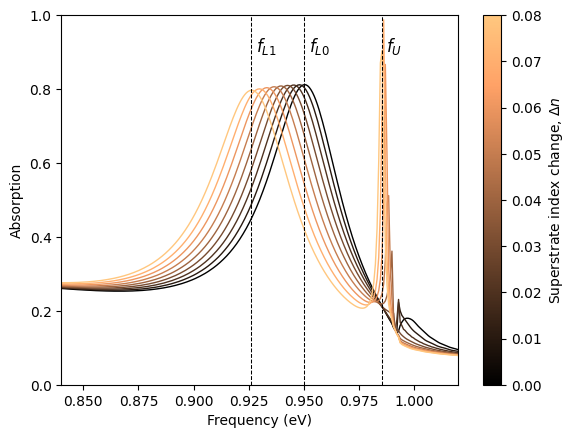

In [12]:
# Peaks are local maxima with negative curvature. Only f_L0, f_L1, and f_U are extracted.
def peak_frequencies_from_derivatives(f, A, n_peaks=2):
    f = np.asarray(f, dtype=float)
    A = np.asarray(A, dtype=float)

    dA_df = np.gradient(A, f)
    d2A_df2 = np.gradient(dA_df, f)

    maxima = np.flatnonzero((dA_df[:-1] > 0) & (dA_df[1:] <= 0))
    candidates = []
    for idx in maxima:
        peak_idx = idx if abs(dA_df[idx]) <= abs(dA_df[idx + 1]) else idx + 1
        if 0 < peak_idx < len(f) - 1 and d2A_df2[peak_idx] < 0:
            candidates.append(peak_idx)

    if len(candidates) < n_peaks:
        valid = d2A_df2 < 0
        valid[:2] = False
        valid[-2:] = False
        idx = np.flatnonzero(valid)
        regions = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1) if len(idx) else []
        for region in regions:
            candidates.append(region[np.argmin(np.abs(dA_df[region]))])

    candidates = np.unique(candidates)
    if len(candidates) < n_peaks:
        raise RuntimeError(f"Found only {len(candidates)} peak candidates.")

    selected = candidates[np.argsort(A[candidates])[-n_peaks:]]
    return np.sort(f[selected])


fig, ax = plt.subplots()
cmap = plt.cm.copper
norm = Normalize(vmin=0, vmax=0.08)

for ii, deln in enumerate(deln_list):
    sim_data = batch_data[f"deln_sweep_{ii}"]
    refl = sim_data["refl"].flux.squeeze()
    trans = sim_data["trans"].flux.squeeze()
    abs_spec = 1 - refl - trans
    f = np.asarray(abs_spec.f)
    E = 2 * np.pi * f * td.HBAR
    A = np.asarray(abs_spec)

    ax.plot(E, A, "-", lw=1, color=cmap(norm(deln)))

    if ii == 0:
        (f_L0,) = peak_frequencies_from_derivatives(f, A, n_peaks=1)
    elif ii == len(deln_list) - 1:
        f_L1, f_U = peak_frequencies_from_derivatives(f, A, n_peaks=2)

ax.set(
    xlabel="Frequency (eV)",
    ylabel="Absorption",
    ylim=(0, 1),
    xlim=(photon_energy_min, photon_energy_max),
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"Superstrate index change, $\Delta n$")

for fv, label in zip([f_L0, f_L1, f_U], [r"$f_{L0}$", r"$f_{L1}$", r"$f_U$"]):
    E_peak = 2 * np.pi * fv * td.HBAR
    ax.axvline(x=E_peak, color="k", lw=0.75, ls="--")
    ax.text(E_peak + 0.002, 0.9, label, fontsize=12)

#### Near-field response in a rotated two-cell supercell

A square domain of side $P_2=P\sqrt{2}$, rotated by 45° relative to the primitive-cell basis, has area $2P^2$ and therefore contains two primitive cells: four sites in total. It is consequently a **rotated two-cell supercell**, not a conventional 2×2 array of four primitive cells. The representation places two A sites and two B sites in one Cartesian periodic domain, making the selected vertical cross-sections convenient for comparing the two site types. 

`make_sim2` starts from `make_sim(**kwargs)` and constructs the rotated two-cell geometry with `updated_copy`. The domain, structures, monitors, and grid snapping points are replaced; the boundary conditions, source, background medium, termination specification, and shutoff threshold are inherited.

> **Dependency:** Run the bulk-index sweep first to obtain the resonance frequencies `f_L0`, `f_L1`, and `f_U`.

In [13]:
def make_sim2(freqs, **kwargs) -> td.Simulation:
    """2×2 supercell FDTD simulation for near-field visualization.

    Calls ``make_sim(**kwargs)`` for the primitive-cell base, then updates it
    to the supercell via ``updated_copy``: domain size, structures, monitors,
    and snapping points are replaced; boundary conditions, source, medium,
    ``run_time``, and ``shutoff`` are inherited unchanged.

    Parameters:
        freqs : array-like of float
            Monitor frequencies (Hz).
        **kwargs : forwarded to ``make_sim`` (geometry, materials, Δn, grid resolution).
    """
    D_A = kwargs.get("D_A", 0.3)
    D_B = kwargs.get("D_B", 0.3)
    Z_A = kwargs.get("Z_A", 0.2)
    Z_B = kwargs.get("Z_B", 0.08)
    t_Au = kwargs.get("t_Au", 50e-3)
    t_TiO2 = kwargs.get("t_TiO2", 130e-3)
    sim_base = make_sim(**kwargs)

    hole_A1 = td.Cylinder(
        axis=2, center=(P2 / 4, P2 / 4, -Z_A / 2), radius=D_A / 2, length=Z_A
    )
    hole_B1 = td.Cylinder(
        axis=2, center=(P2 / 4, -P2 / 4, -Z_B / 2), radius=D_B / 2, length=Z_B
    )
    hole_A2 = td.Cylinder(
        axis=2, center=(-P2 / 4, -P2 / 4, -Z_A / 2), radius=D_A / 2, length=Z_A
    )
    hole_B2 = td.Cylinder(
        axis=2, center=(-P2 / 4, P2 / 4, -Z_B / 2), radius=D_B / 2, length=Z_B
    )

    geom_sub = td.ClipOperation(
        operation="difference",
        geometry_a=td.Box(
            center=(0, 0, -sim_size_z_minus),
            size=(td.inf, td.inf, sim_size_z_minus * 2),
        ),
        geometry_b=td.GeometryGroup(geometries=[hole_A1, hole_B1, hole_A2, hole_B2]),
    )
    substrate = td.Structure(geometry=geom_sub, medium=NOA83, name="substrate")

    deposit_au = [
        td.Structure(
            geometry=td.Cylinder(
                axis=2,
                center=(
                    s1 * P2 / 4,
                    s2 * P2 / 4,
                    -(Z_A if s1 == s2 else Z_B) + t_Au / 2,
                ),
                radius=(D_A if s1 == s2 else D_B) / 2,
                length=t_Au,
            ),
            medium=Au,
            name=f"au_{s1}_{s2}",
        )
        for s1 in [-1, 1]
        for s2 in [-1, 1]
    ]
    deposit_au_sub = td.Structure(
        geometry=td.ClipOperation(
            operation="difference",
            geometry_a=td.Box(center=(0, 0, t_Au / 2), size=(td.inf, td.inf, t_Au)),
            geometry_b=td.GeometryGroup(
                geometries=[
                    td.Cylinder(
                        axis=2,
                        center=(s1 * P2 / 4, s2 * P2 / 4, t_Au / 2),
                        radius=(D_A if s1 == s2 else D_B) / 2,
                        length=t_Au,
                    )
                    for s1 in [-1, 1]
                    for s2 in [-1, 1]
                ]
            ),
        ),
        medium=Au,
        name="au-sub",
    )

    deposit_tio2 = [
        td.Structure(
            geometry=td.Cylinder(
                axis=2,
                center=(
                    s1 * P2 / 4,
                    s2 * P2 / 4,
                    -(Z_A if s1 == s2 else Z_B) + t_Au + t_TiO2 / 2,
                ),
                radius=(D_A if s1 == s2 else D_B) / 2,
                length=t_TiO2,
            ),
            medium=TiO2,
            name=f"tio2_{s1}_{s2}",
        )
        for s1 in [-1, 1]
        for s2 in [-1, 1]
    ]
    deposit_tio2_sub = td.Structure(
        geometry=td.ClipOperation(
            operation="difference",
            geometry_a=td.Box(
                center=(0, 0, t_Au + t_TiO2 / 2), size=(td.inf, td.inf, t_TiO2)
            ),
            geometry_b=td.GeometryGroup(
                geometries=[
                    td.Cylinder(
                        axis=2,
                        center=(s1 * P2 / 4, s2 * P2 / 4, t_Au + t_TiO2 / 2),
                        radius=(D_A if s1 == s2 else D_B) / 2,
                        length=t_TiO2,
                    )
                    for s1 in [-1, 1]
                    for s2 in [-1, 1]
                ]
            ),
        ),
        medium=TiO2,
        name="tio2-sub",
    )

    mnt_refl = sim_base.monitors[0].updated_copy(freqs=freqs)
    mnt_trans = sim_base.monitors[1].updated_copy(freqs=freqs)
    mnt_vert1 = td.FieldMonitor(
        center=(P2 / 4, P2 / 4, 0),
        size=(0, td.inf, td.inf),
        freqs=freqs,
        name="vert1",
    )
    mnt_vert2 = td.FieldMonitor(
        center=(P2 / 4, P2 / 4, 0),
        size=(td.inf, 0, td.inf),
        freqs=freqs,
        name="vert2",
    )

    grid_spec = sim_base.grid_spec.updated_copy(
        snapping_points=[
            (P2 / 4, P2 / 4, sim_base.sources[0].center[2]),
            (-P2 / 4, -P2 / 4, mnt_refl.center[2]),
            (0, 0, mnt_trans.center[2]),
        ],
    )

    return sim_base.updated_copy(
        size=(P2, P2, sim_base.size[2]),
        structures=[
            substrate,
            *deposit_au,
            deposit_au_sub,
            *deposit_tio2,
            deposit_tio2_sub,
        ],
        monitors=[mnt_refl, mnt_trans, mnt_vert1, mnt_vert2],
        grid_spec=grid_spec,
    )


sim_field = make_sim2(freqs=[f_L1, f_L0, f_U])
sim_field.plot_3d()

#### Near fields visualization

Two rotated-supercell simulations are evaluated at $\Delta n=0$ and 0.08 RIU using $Z_A=194$ nm, $Z_B=30$ nm, and $t_\mathrm{TiO_2}=60$ nm.

             Found all simulations in cache.

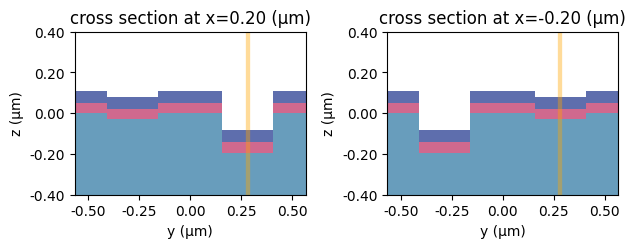

In [14]:
deln_list = [0, 0.08]
sims = {
    f"deln_sweep_{ii}": make_sim2(
        Z_A=194 * nm,
        Z_B=30 * nm,
        t_TiO2=60 * nm,
        deln_bulk=deln,
        freqs=[f_L1, f_L0, f_U],
    )
    for ii, deln in enumerate(deln_list)
}

batch_data = web.run_async(
    simulations=sims,
    verbose=True,
    folder_name="NatPhoton2026",
    path_dir="./data/deltan_field",
)

fig, ax = plt.subplots(1, 2, tight_layout=True)
sims[f"deln_sweep_{0}"].plot(x=P / 4, ax=ax[0])
sims[f"deln_sweep_{0}"].plot(x=-P / 4, ax=ax[1])
ax[0].set(ylim=(-P / 2, P / 2))
ax[1].set(ylim=(-P / 2, P / 2));

Each qBIC branch is sampled at its own absorption-peak frequency for each refractive index. This avoids comparing one state on resonance with the other state at an off-resonant frequency.

Tidy3D normalizes a periodic `PlaneWave` to 1 W per simulation cell. In these simulations the plane-wave source is placed below the deepest holes, inside the NOA83 substrate for every superstrate index. Accordingly, the incident field amplitude used below is $E_\mathrm{inc}=\sqrt{2Z_\mathrm{sub}/A}$, where $Z_\mathrm{sub}=\eta_0/n_\mathrm{sub}$ is the wave impedance of NOA83 and $A=P_2^2$ is the supercell area.

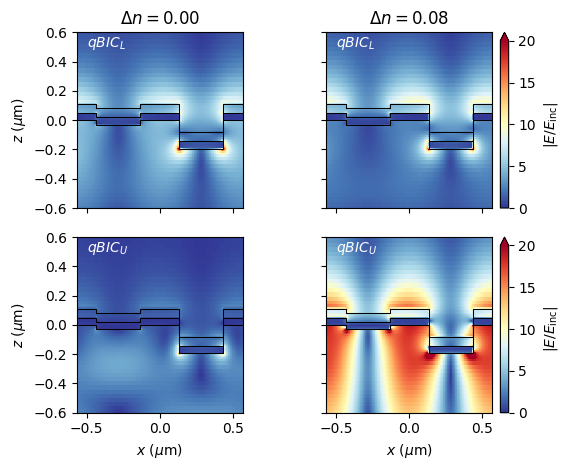

In [15]:
n_sub = NOA83.nk_model(frequency=freq0)[0]
Z_sub = td.ETA_0 / n_sub
E_inc = np.sqrt(2 * Z_sub / P2**2)

fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, tight_layout=True)
cmap = plt.cm.RdYlBu_r
Z_A = 194 * nm
Z_B = 30 * nm
D = 0.3
t_TiO2 = 60e-3
t_Au = 50e-3
x_grid = np.array(
    [
        -P2 / 2,
        -D / 2 - P2 / 4,
        -D / 2 - P2 / 4,
        D / 2 - P2 / 4,
        D / 2 - P2 / 4,
        -D / 2 + P2 / 4,
        -D / 2 + P2 / 4,
        D / 2 + P2 / 4,
        D / 2 + P2 / 4,
        P2 / 2,
    ]
)
baseline = np.array([0, 0, -Z_B, -Z_B, 0, 0, -Z_A, -Z_A, 0, 0])

for ii in range(2):
    sim_data = batch_data[f"deln_sweep_{ii}"]
    f_sel = [f_L0 if ii == 0 else f_L1, f_U]
    Ex = sim_data["vert2"].Ex.sel(f=f_sel).squeeze()
    Ey = sim_data["vert2"].Ey.sel(f=f_sel).squeeze()
    Ez = sim_data["vert2"].Ez.sel(f=f_sel).squeeze()
    E = np.sqrt(np.abs(Ex) ** 2 + np.abs(Ey) ** 2 + np.abs(Ez) ** 2) / E_inc
    x, z = np.meshgrid(E.x, E.z, indexing="ij")
    for jj in range(2):
        mode = "L" if jj == 0 else "U"
        pc = ax[jj, ii].pcolormesh(x, z, E[..., jj], vmin=0, vmax=20, cmap=cmap)
        ax[jj, ii].set_aspect("equal")
        ax[0, ii].set_title(rf"$\Delta n = {0.08 * ii:.2f}$")
        ax[jj, ii].text(-0.5, 0.5, rf"$qBIC_{{{mode}}}$", color="w")
        ax[jj, ii].plot(x_grid, baseline, color="k", lw=0.75)
        ax[jj, ii].plot(x_grid, baseline + t_Au, color="k", lw=0.75)
        ax[jj, ii].plot(x_grid, baseline + t_Au + t_TiO2, color="k", lw=0.75)

        if ii == 1:
            cax = ax[jj, ii].inset_axes([1.05, 0, 0.05, 1])
            cbar = plt.colorbar(pc, cax=cax, extend="max")
            cbar.ax.set_ylabel(r"$|E/E_\mathrm{inc}|$")

ax[1, 0].set(
    xlim=(-P2 / 2, P2 / 2),
    ylim=(-0.6, 0.6),
    xlabel=r"$x$ ($\mu$m)",
    ylabel=r"$z$ ($\mu$m)",
)
ax[0, 0].set(ylabel=r"$z$ ($\mu$m)")
ax[1, 1].set(xlabel=r"$x$ ($\mu$m)");